### Importando Bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Carregando os dados

In [4]:
df = pd.read_csv(r'../data/raw/dados_brutos.csv')

In [5]:
df.shape

(10000, 14)

In [6]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df.sample(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1636,1637,L48816,L,297.9,307.8,1505,37.3,100,0,0,0,0,0,0
9302,9303,M24162,M,298.1,308.9,1804,25.1,118,0,0,0,0,0,0
1186,1187,L48366,L,297.3,308.4,1417,47.8,31,0,0,0,0,0,0
4597,4598,M19457,M,303.0,311.1,1490,43.0,108,0,0,0,0,0,0
5298,5299,M20158,M,303.7,313.1,2130,18.1,185,0,0,0,0,0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

### Verificar valores inconsistentes

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


### Verificando valores faltantes

In [10]:
missing = (
    df.isnull()
        .sum()
        .sort_values(ascending=False)
)
missing


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

### Verificando Valores duplicados

In [11]:
df.duplicated().sum()

np.int64(0)

### Verificar Tipos de dados

In [12]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

### Cardinalidade

In [13]:
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [28]:
''' Colunas sao praticamente derivadas da variável Machine failure'''
df=df.drop(
    columns=[
        'TWF',
        'HDF',
        'PWF',
        'OSF',
        'RNF'
    ]
)


### Colacar as temperaturas em graus celcius

In [52]:
df['Air temperature [°C]'] = (
    df['Air temperature [K]'] - 273.15
)

df['Process temperature [°C]'] = (
    df['Process temperature [K]'] - 273.15
)
df = df.drop(
    columns=[
        'Air temperature [K]',
        'Process temperature [K]'
        
    ]
)

### Distruição das variaveis numericas

In [53]:
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

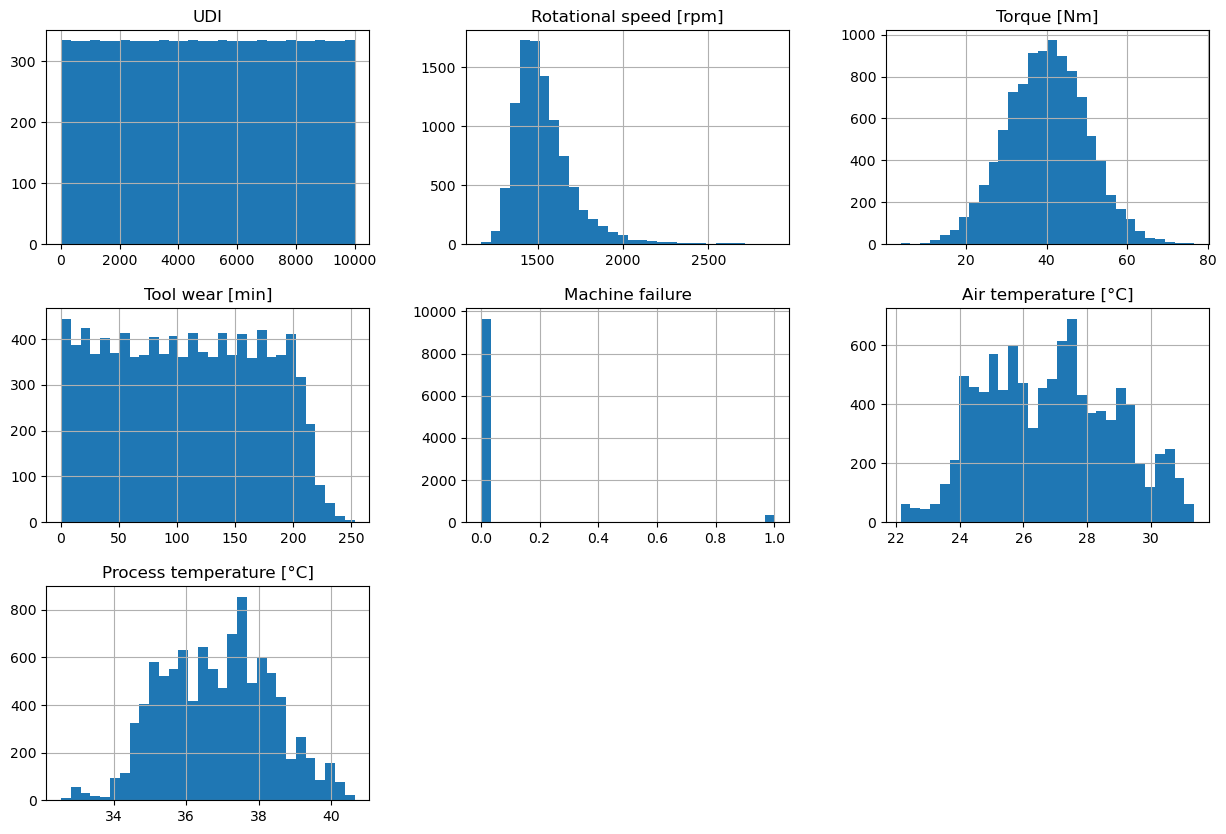

In [54]:
df[num_cols].hist(
    figsize=(15,10),
    bins=30
)
plt.show()

### Boxplots

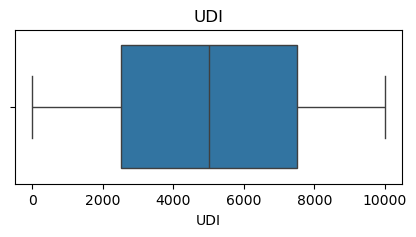

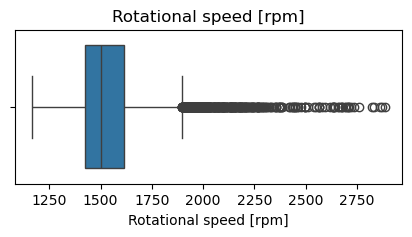

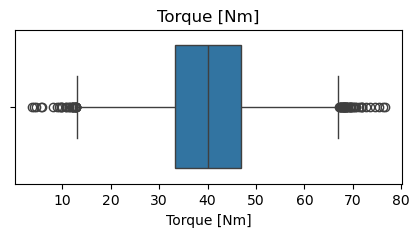

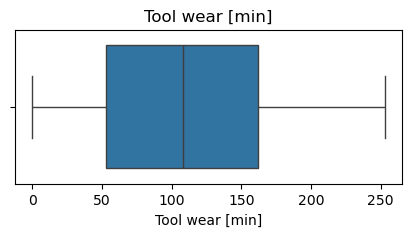

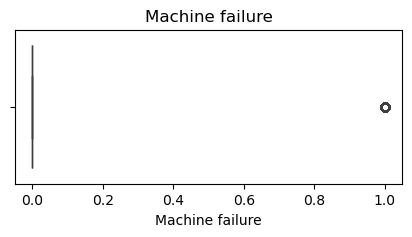

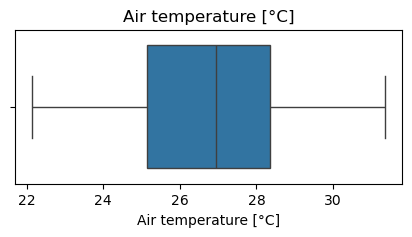

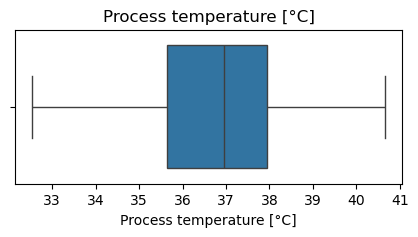

In [55]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(
        x=df[col]
    )
    plt.title(col)
    plt.show

### Verificar Desbalanceamento

In [56]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [33]:
''' EM percentual'''
df['Machine failure'].value_counts(normalize=True)*100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

### Correlação

<Axes: >

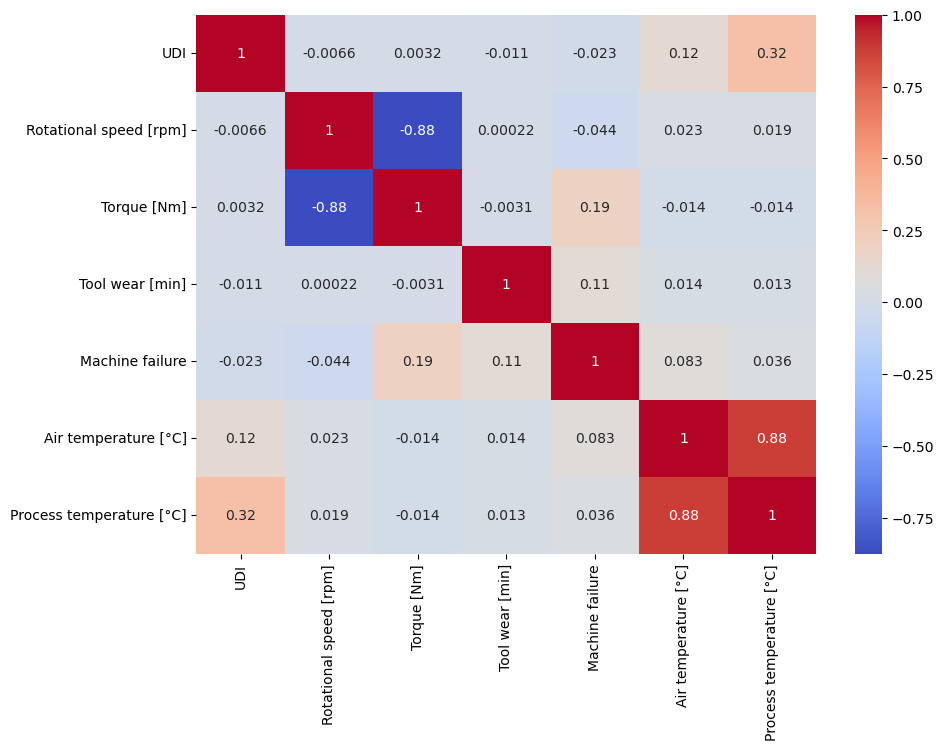

In [57]:
plt.figure(figsize=(10,7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

### Distribuição por falha

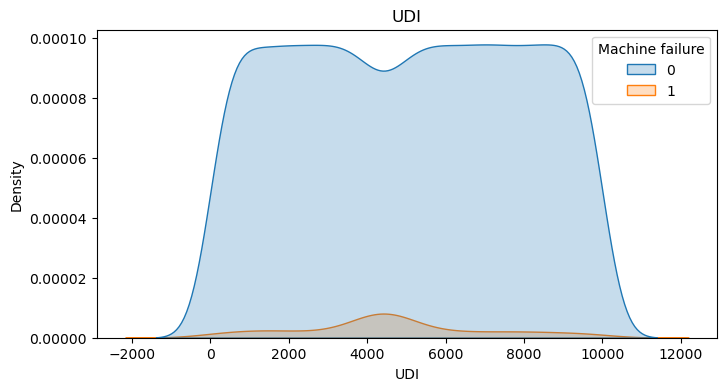

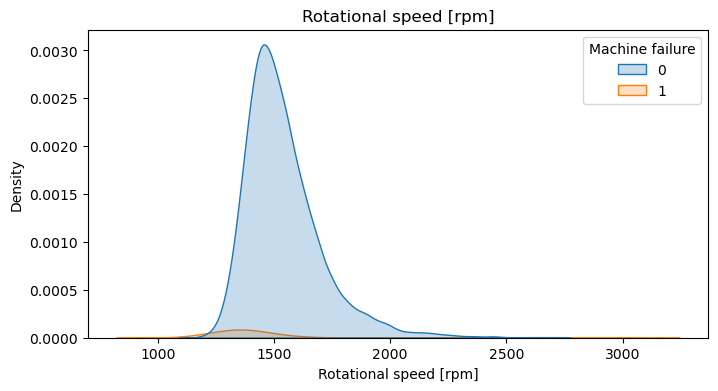

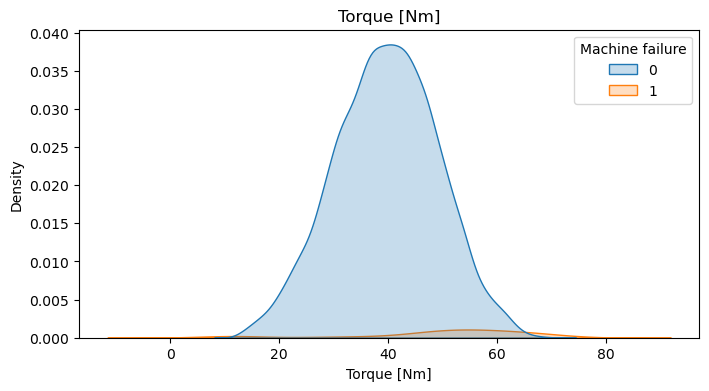

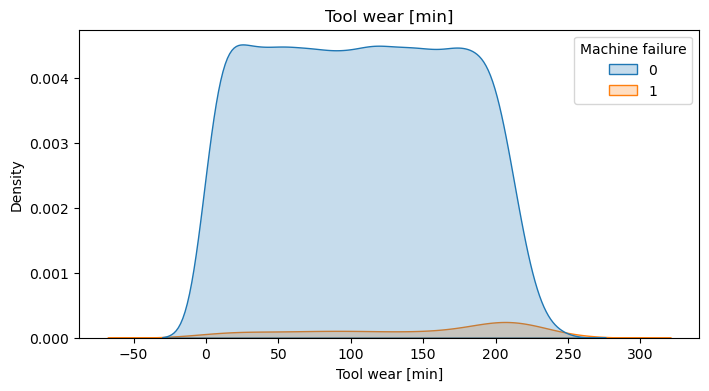

C:\Users\User\AppData\Local\Temp\ipykernel_6592\99528943.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


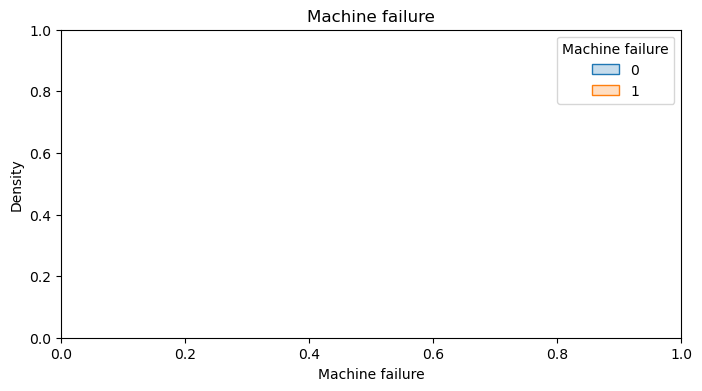

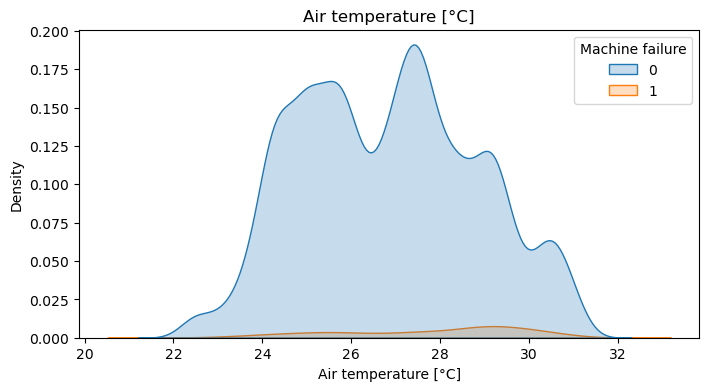

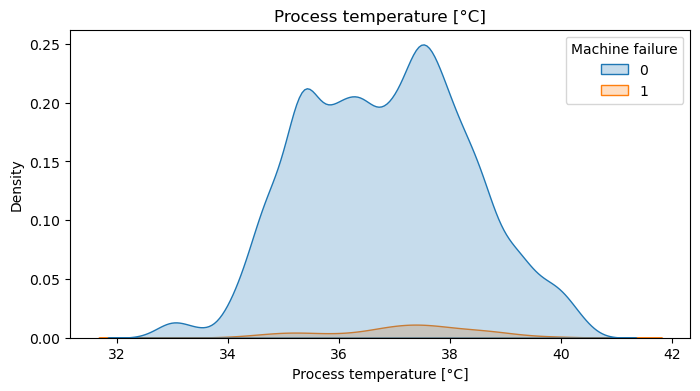

In [58]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(
        data=df,
        x=col,
        hue='Machine failure',
        fill=True
    )
    plt.title(col)
    plt.show()

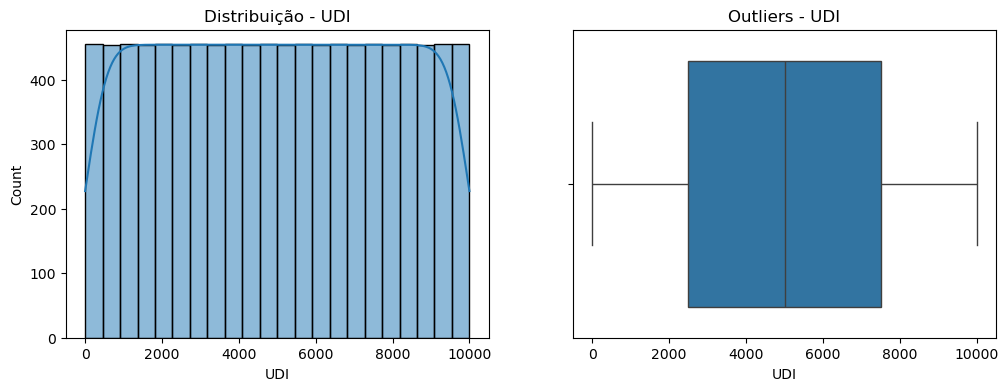

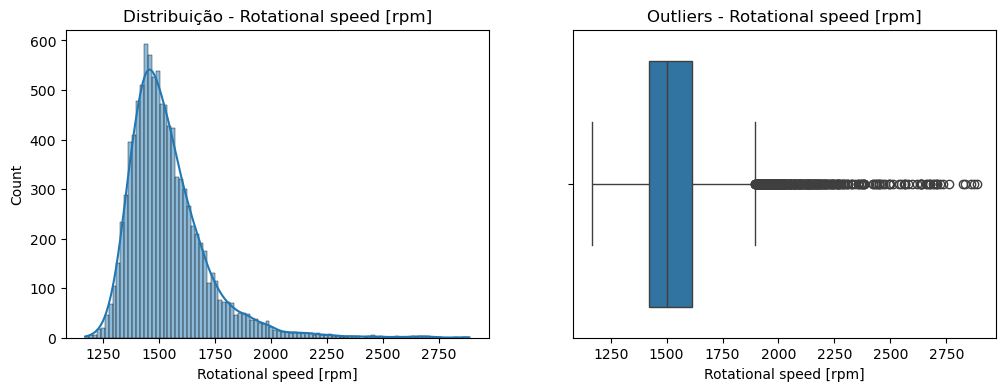

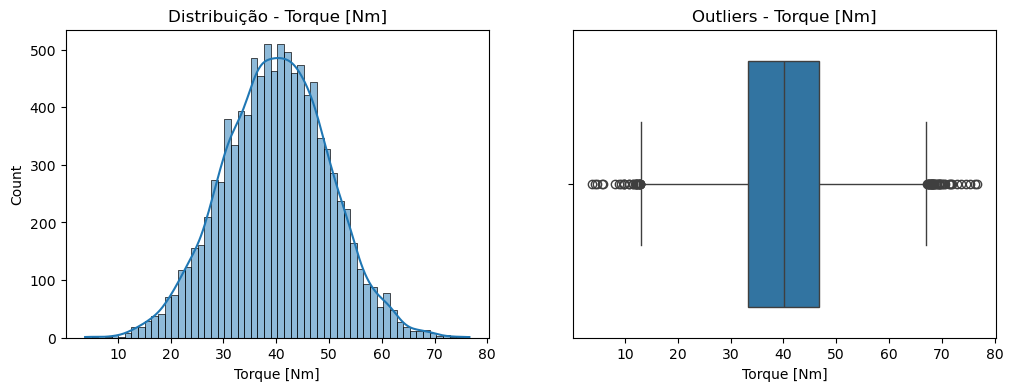

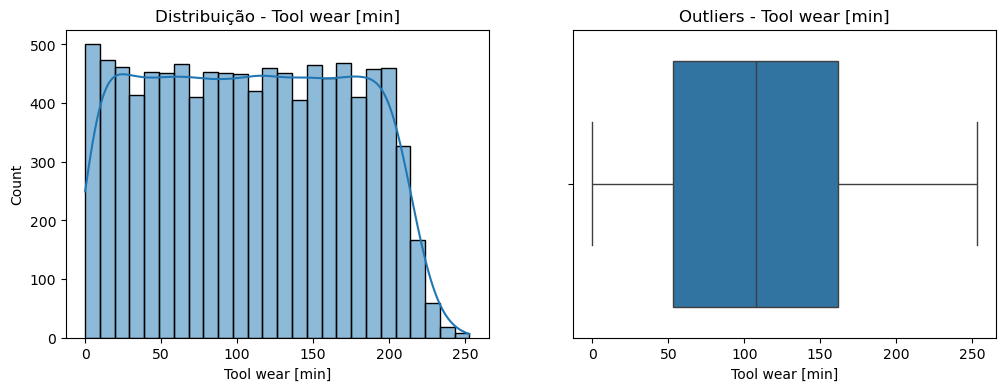

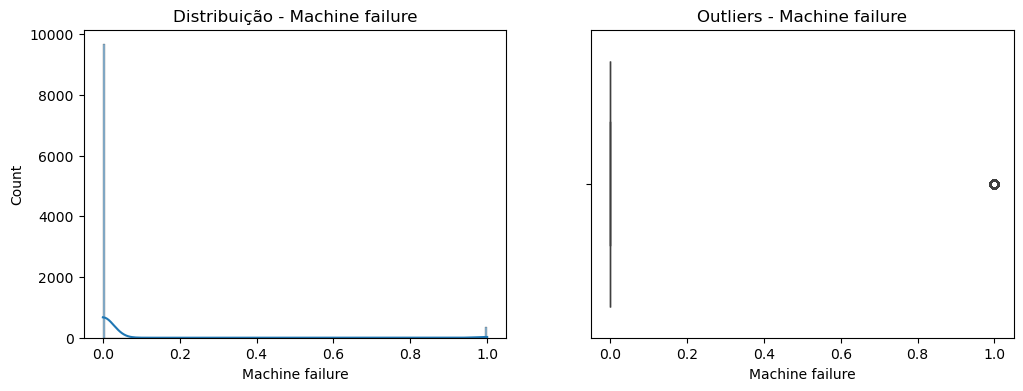

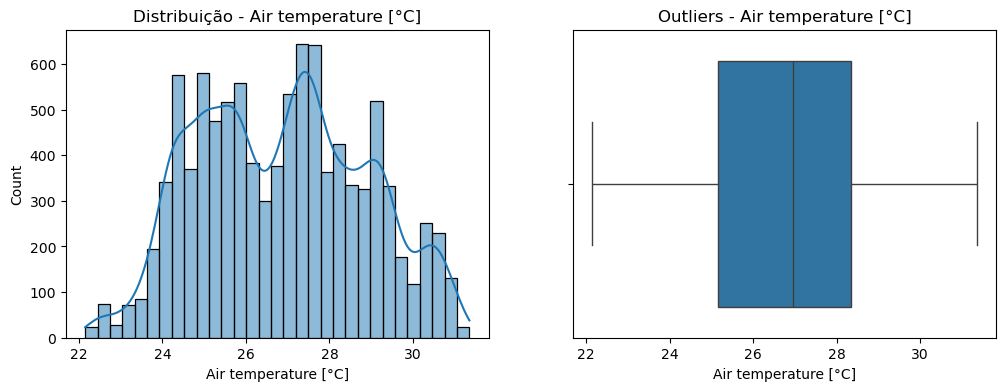

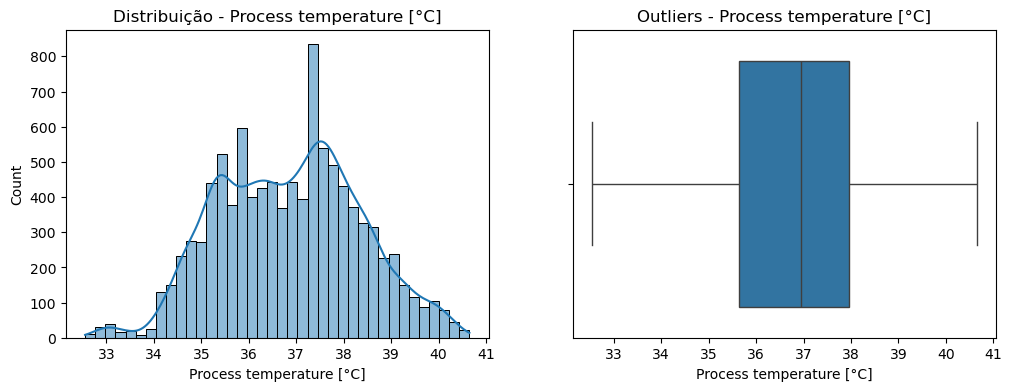

In [59]:
for col in num_cols:

    fig, ax = plt.subplots(
        1, 2,
        figsize=(12,4)
    )

    sns.histplot(
        df[col],
        kde=True,
        ax=ax[0]
    )

    sns.boxplot(
        x=df[col],
        ax=ax[1]
    )

    ax[0].set_title(f'Distribuição - {col}')
    ax[1].set_title(f'Outliers - {col}')

    plt.show()

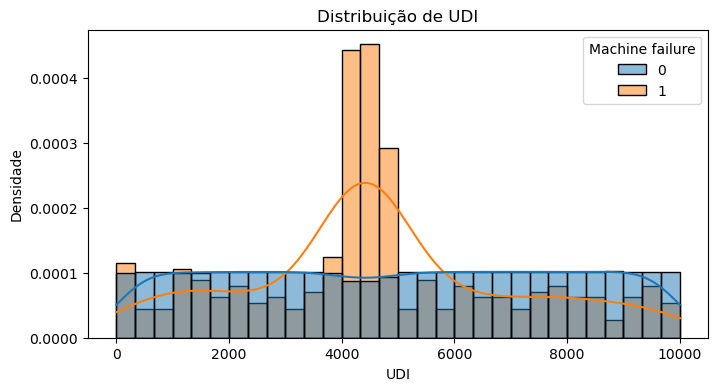

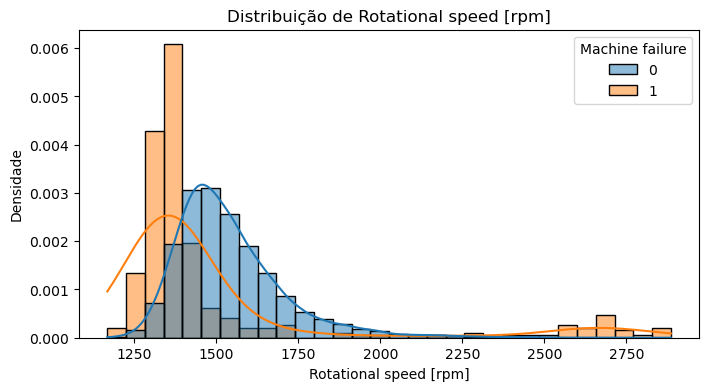

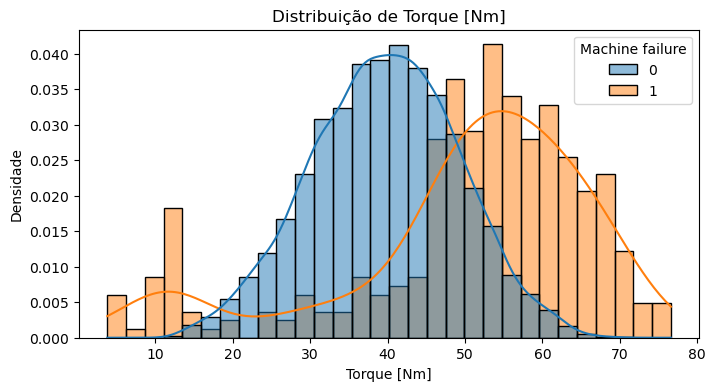

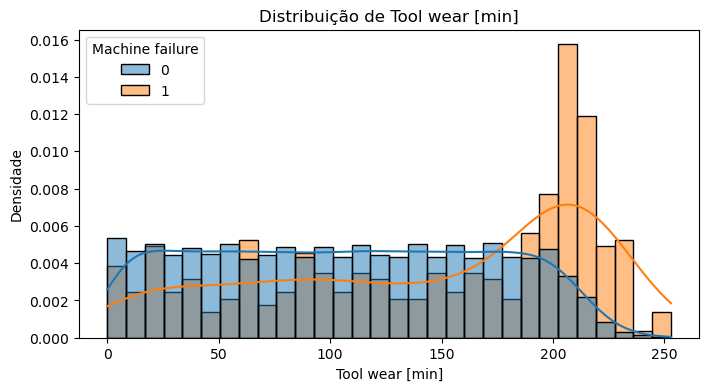

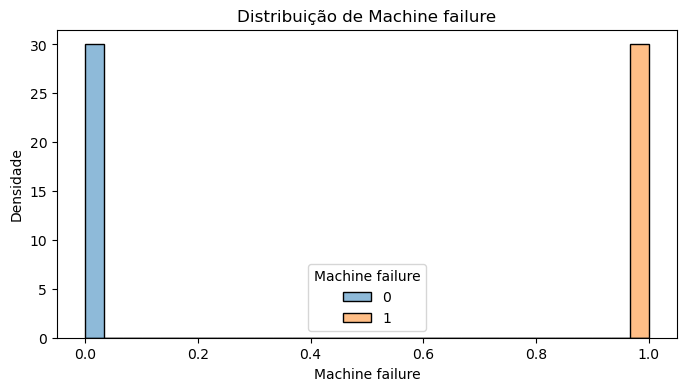

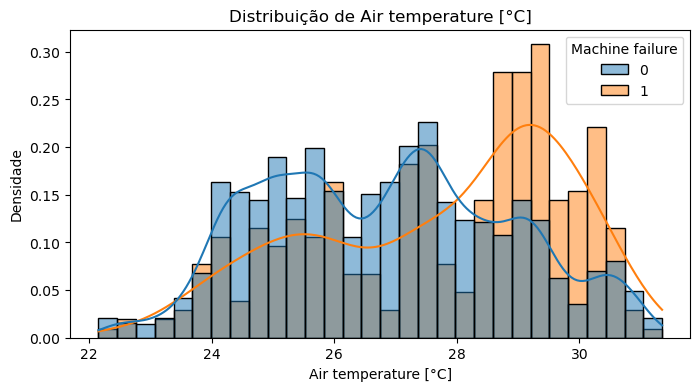

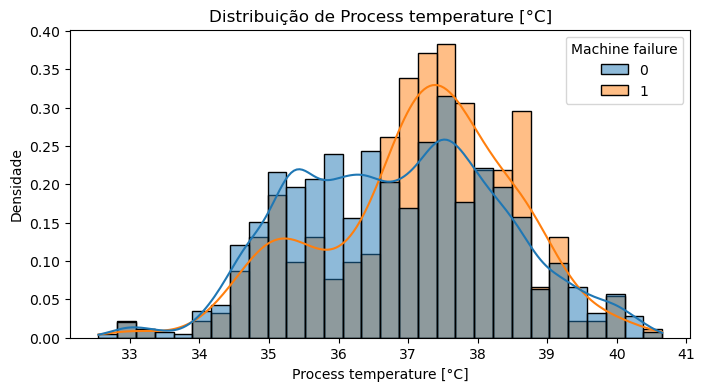

In [60]:
for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=col,
        hue='Machine failure',
        bins=30,
        kde=True,
        stat='density',
        common_norm=False
    )

    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Densidade')

    plt.show()

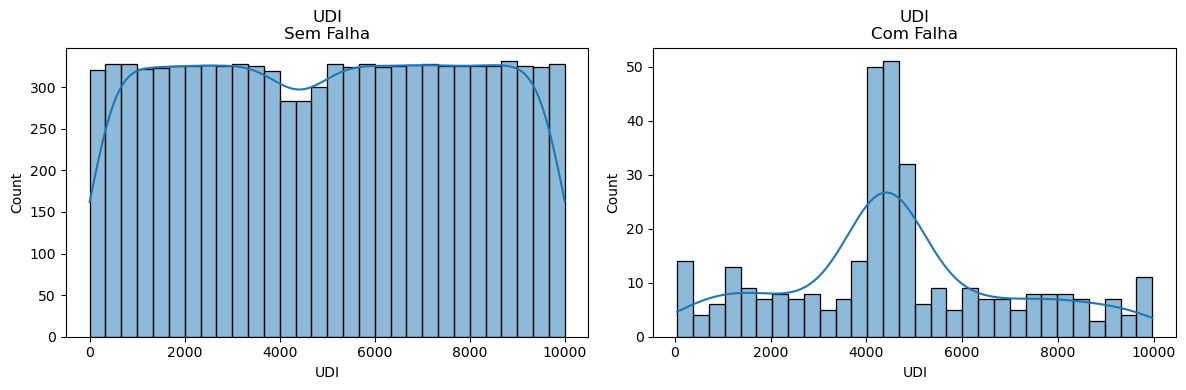

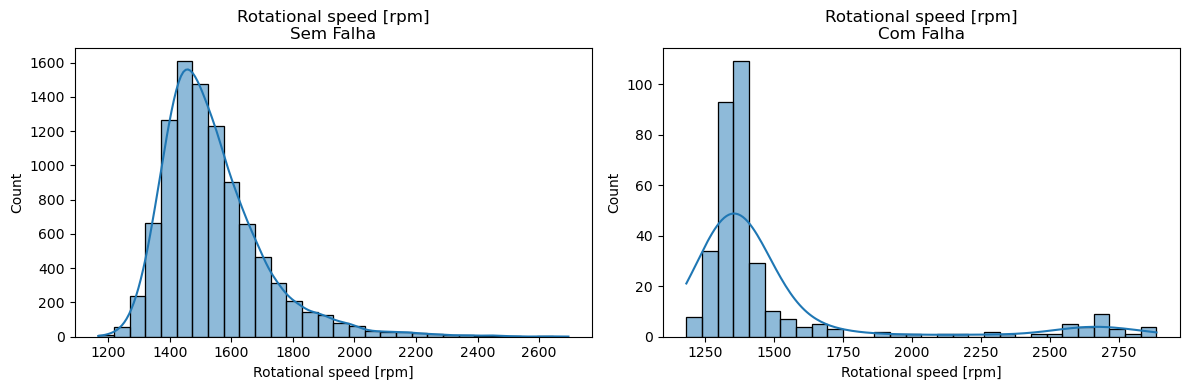

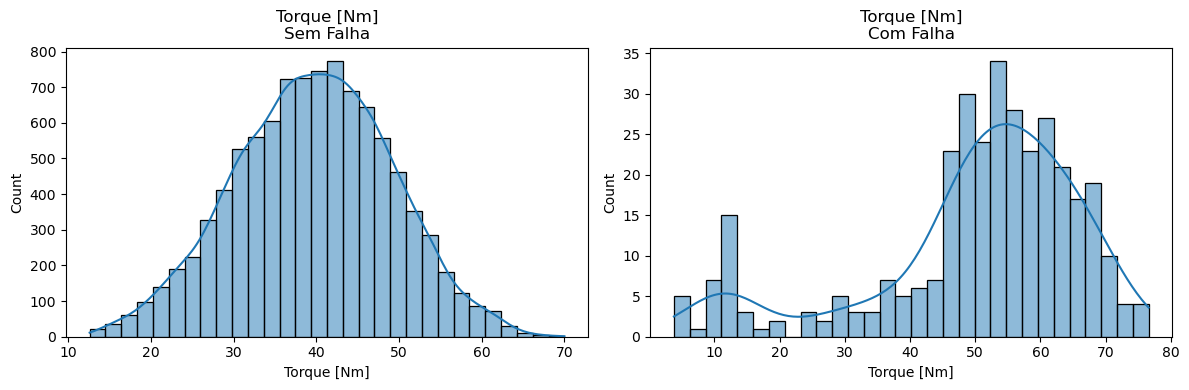

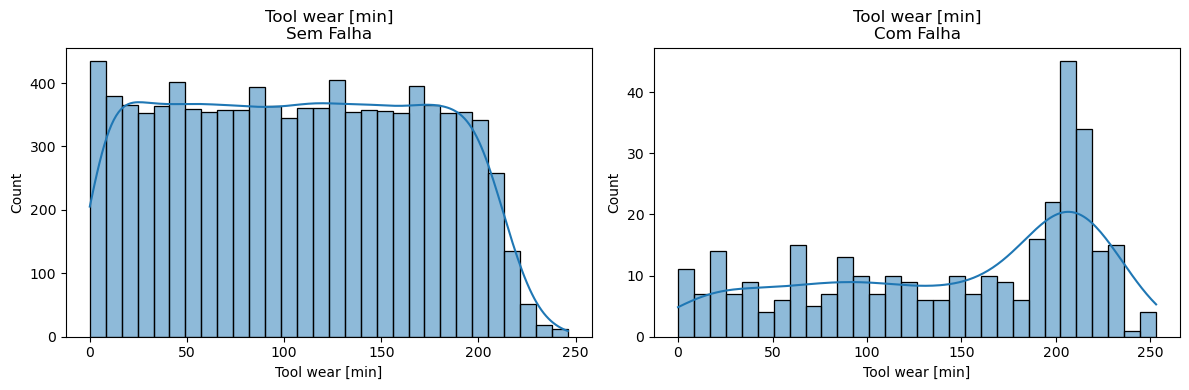

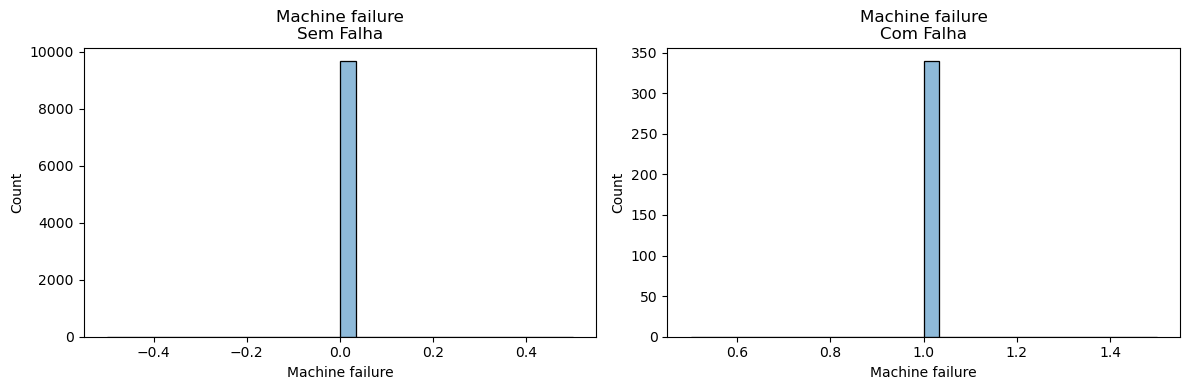

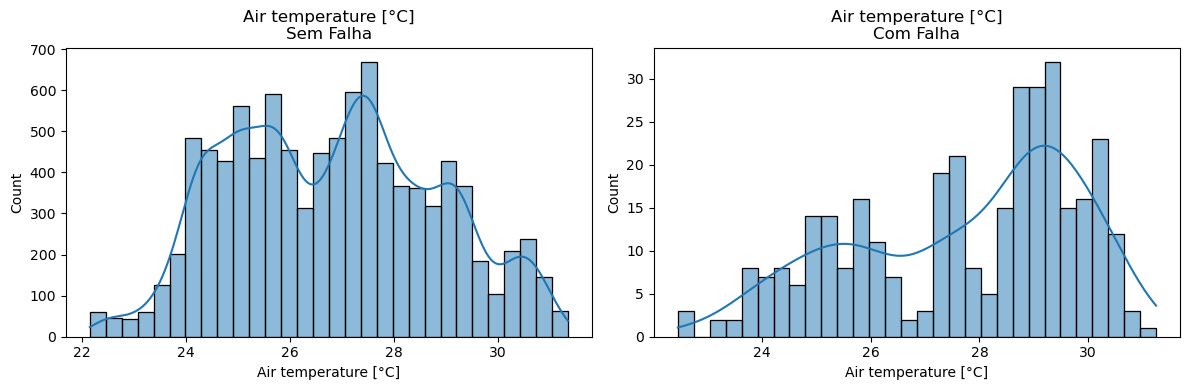

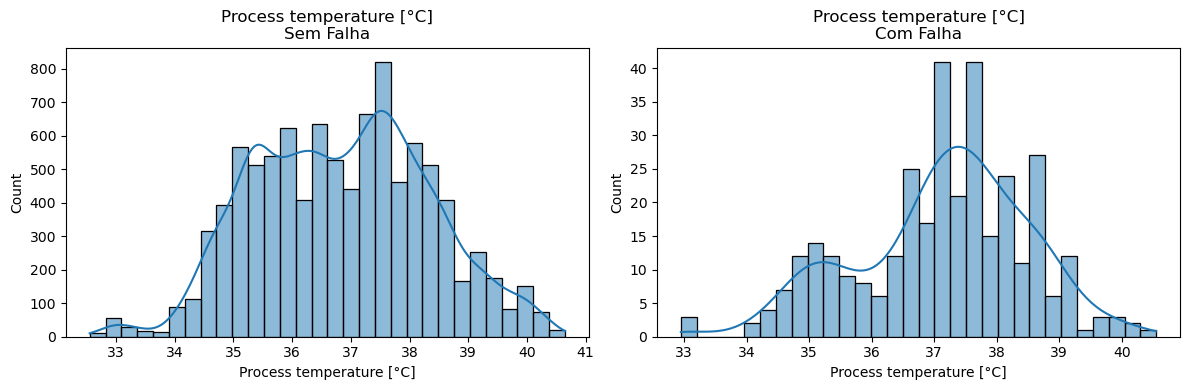

In [61]:
for col in num_cols:

    fig, ax = plt.subplots(
        1, 2,
        figsize=(12,4)
    )

    sns.histplot(
        df[df['Machine failure']==0][col],
        bins=30,
        kde=True,
        ax=ax[0]
    )

    ax[0].set_title(
        f'{col}\nSem Falha'
    )

    sns.histplot(
        df[df['Machine failure']==1][col],
        bins=30,
        kde=True,
        ax=ax[1]
    )

    ax[1].set_title(
        f'{col}\nCom Falha'
    )

    plt.tight_layout()
    plt.show()

### Salvar dados tratados

In [16]:
df.to_csv('../data/processed/predictive_maintenance_clean.csv', index=False)